### Homework 5: Question search engine

Remeber week01 where you used GloVe embeddings to find related questions? That was.. cute, but far from state of the art. It's time to really solve this task using context-aware embeddings.

__Warning:__ this task assumes you have seen `seminar.ipynb`!

In [1]:
%pip install --upgrade transformers datasets accelerate deepspeed
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
import datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.4 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 100.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.3/553.3 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 4.4 MB/s eta 0:00:00
  Created wheel for deepspeed: filename=deepspeed-0.18.5-py3-none-any.whl size=1779414 sha256=7224e92efffecf0ee847a1a36a24f57611468af86cc2c56ecd7b46b804e8418b
  Stored in directory: /root/.cache/pip/wheels/44/33/49/3e1af5a691f90c9acbec4ae97ff99d6b05f3cdf963fb12298f
Successfully built deepspeed
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.36.0
    Uninstalling huggingface-hub-0.36.0:
      Successfully uninstalle

### Load data and model

In [2]:
qqp = datasets.load_dataset('SetFit/qqp')
print('\n')
print("Sample[0]:", qqp['train'][0])
print("Sample[3]:", qqp['train'][3])

README.md:   0%|          | 0.00/313 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/70.8M [00:00<?, ?B/s]

validation.jsonl: 0.00B [00:00, ?B/s]

test.jsonl:   0%|          | 0.00/76.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/363846 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/40430 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/390965 [00:00<?, ? examples/s]



Sample[0]: {'text1': 'How is the life of a math student? Could you describe your own experiences?', 'text2': 'Which level of prepration is enough for the exam jlpt5?', 'label': 0, 'idx': 0, 'label_text': 'not duplicate'}
Sample[3]: {'text1': 'What can one do after MBBS?', 'text2': 'What do i do after my MBBS ?', 'label': 1, 'idx': 3, 'label_text': 'duplicate'}


In [3]:
model_name = "gchhablani/bert-base-cased-finetuned-qqp"
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)
model = transformers.AutoModelForSequenceClassification.from_pretrained(model_name)

config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: gchhablani/bert-base-cased-finetuned-qqp
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Tokenize the data

In [4]:
MAX_LENGTH = 128
def preprocess_function(examples):
    result = tokenizer(
        examples['text1'], examples['text2'],
        padding='max_length', max_length=MAX_LENGTH, truncation=True
    )
    result['label'] = examples['label']
    return result

qqp_preprocessed = qqp.map(preprocess_function, batched=True)

Map:   0%|          | 0/363846 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Map:   0%|          | 0/40430 [00:00<?, ? examples/s]

Map:   0%|          | 0/390965 [00:00<?, ? examples/s]

In [5]:
print(repr(qqp_preprocessed['train'][0]['input_ids'])[:100], "...")

[101, 1731, 1110, 1103, 1297, 1104, 170, 12523, 2377, 136, 7426, 1128, 5594, 1240, 1319, 5758, 136,  ...


### Task 1: evaluation (1 point)

We randomly chose a model trained on QQP - but is it any good?

One way to measure this is with validation accuracy - which is what you will implement next.

Here's the interface to help you do that:

In [6]:
val_set = qqp_preprocessed['validation']
val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=64, shuffle=False, collate_fn=transformers.default_data_collator, num_workers=4
)

val_quick_d = qqp_preprocessed['validation'].select(range(1000))
val_quick = torch.utils.data.DataLoader(
    val_quick_d, batch_size=64, shuffle=False, collate_fn=transformers.default_data_collator, num_workers=4
)

train_set = qqp_preprocessed['train']
train_loader = torch.utils.data.DataLoader(
    val_set, batch_size=64, shuffle=False, collate_fn=transformers.default_data_collator, num_workers=4
)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

start loss: 0.3771


/tmp/ipykernel_80/1086130963.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To d

Epoch 1, Step 25/632, Train Loss: 0.0743, Val Loss: 0.3473


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

...

Epoch 1, Step 575/632, Train Loss: 0.2023, Val Loss: 0.2367


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch 1, Step 600/632, Train Loss: 0.2271, Val Loss: 0.2344


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch 1, Step 625/632, Train Loss: 0.1710, Val Loss: 0.2314


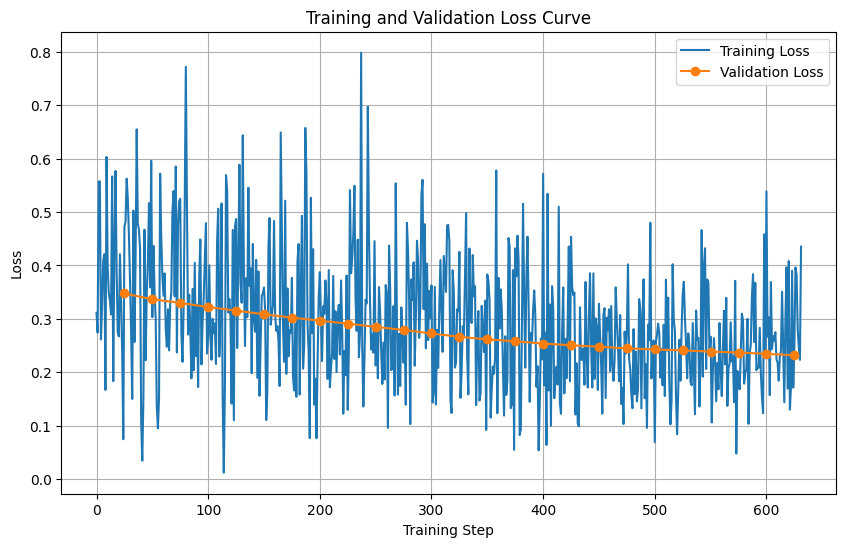

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Fial loss: 0.2309, model size: 433M


In [7]:
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
def evaluate_val_loss(model, val_loader, device):
    model.eval()
    total_loss = 0.0
    count = 0

    with torch.no_grad():
        for batch in val_loader:
            labels = batch['labels'].to(device)
            model_inputs = {k: v.to(device) for k, v in batch.items()
                            if k in {"input_ids", "attention_mask", "token_type_ids"}}

            pred = model(**model_inputs)
            logits = pred.logits
            loss = F.cross_entropy(logits, labels)

            total_loss += loss.item() * labels.size(0)
            count += labels.size(0)

    mean_loss = total_loss / count
    return mean_loss

mean_val_loss = evaluate_val_loss(model, val_quick, device)
print(f"start loss: {mean_val_loss:.4f}")

def train_model(model, train_loader, val_loader, device, epochs, lr_op=None):
    model.to(device)
    if not lr_op:
      opt = torch.optim.AdamW(model.parameters(), lr=1e-6)
    else:
      opt = torch.optim.AdamW(model.parameters(), lr=lr_op)
    scaler = torch.cuda.amp.GradScaler()

    train_losses = []
    val_losses = []
    steps = []

    global_step = 0
    for epoch in range(epochs):
        model.train()
        for i, batch in enumerate(train_loader):
            labels = batch['labels'].to(device)
            model_inputs = {k: v.to(device) for k, v in batch.items()
                            if k in {"input_ids", "attention_mask", "token_type_ids"}}

            with torch.cuda.amp.autocast(dtype=torch.float16):
                pred = model(**model_inputs)
                logits = pred.logits
                loss = F.cross_entropy(logits, labels)

            opt.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            train_losses.append(loss.item())
            global_step += 1

            if global_step % 25 == 0:
                val_loss = evaluate_val_loss(model, val_loader, device)
                val_losses.append(val_loss)
                steps.append(global_step)
                print(f"Epoch {epoch+1}, Step {i+1}/{len(train_loader)}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss:.4f}")

    # Plot training and validation loss
    plt.figure(figsize=(10,6))
    plt.plot(train_losses, label="Training Loss")
    plt.plot(steps, val_losses, label="Validation Loss", marker='o')
    plt.xlabel("Training Step")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

train_model(model, train_loader, val_quick, device, 1)

mean_val_loss = evaluate_val_loss(model, val_quick, device)
print(f"Fial loss: {mean_val_loss:.4f}, model size: 433M")

__Your task__ is to measure the validation accuracy of your model.
Doing so naively may take several hours. Please make sure you use the following optimizations:

- run the model on GPU with no_grad
- using batch size larger than 1
- use optimize data loader with num_workers > 1
- (optional) use [mixed precision](https://pytorch.org/docs/stable/notes/amp_examples.html)


In [8]:
# final loss on valdation data is 0.22 while base model performed: 0.37
# as I see there are fluctuations in the train loss I suppose more epoch needed
# but val loss declinessteadily (that is good):
# as I undertand accuracy is roughtly correct/total?
import time

def evaluate_val_accuracy(model, val_loader, device):
    model.eval()
    correct = 0
    total = 0

    start_time = time.time()

    with torch.no_grad():
        for i, batch in enumerate(val_loader):
            labels = batch['labels'].to(device)
            model_inputs = {k: v.to(device) for k, v in batch.items()
                            if k in {"input_ids", "attention_mask", "token_type_ids"}}
            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                pred = model(**model_inputs)
                logits = pred.logits

            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            if i % 100 == 0:
                print(f"progress: {i}/{len(val_loader)}")

    end_time = time.time()
    elapsed_time = end_time - start_time
    speed_per_sample = elapsed_time / total
    accuracy = correct / total
    print(accuracy, speed_per_sample)
    return accuracy, speed_per_sample

accuracy, speed_per_sample = evaluate_val_accuracy(model, val_loader, device)
print("so accurasy is: ", accuracy, "speed per sample: ", speed_per_sample)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

progress: 0/632
progress: 100/632
progress: 200/632
progress: 300/632
progress: 400/632
progress: 500/632
progress: 600/632
0.9217660153351471 0.0016558429435901702
so accurasy is:  0.9217660153351471 speed per sample:  0.0016558429435901702


In [9]:
# I do not know what to expect as I tuned the model,
# probably it should be more than 0.91 limit (for not trained)

# I will initialize another model and test it:
model_untrained = transformers.AutoModelForSequenceClassification.from_pretrained(model_name)
model_untrained.to(device)
accuracy,  speed_per_sample = evaluate_val_accuracy(model_untrained, val_loader, device)
print("so accurasy is: ", accuracy, "speed per sample: (same)",  speed_per_sample)

assert 0.9 < accuracy < 0.91

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: gchhablani/bert-base-cased-finetuned-qqp
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false

progress: 0/632
progress: 100/632
progress: 200/632
progress: 300/632
progress: 400/632
progress: 500/632
progress: 600/632
0.9084095968340341 0.0016563866712243256
so accurasy is:  0.9084095968340341 speed per sample: (same) 0.0016563866712243256


0.9084095968340341 0.0016563866712243256
so accurasy is:  0.9084095968340341 speed per sample: (same) 0.0016563866712243256

### Task 2: train the model (4 points)

For this task, you have two options:

__Option A:__ fine-tune your own model. You are free to choose any model __except for the original BERT.__ We recommend [DeBERTa-v3](https://huggingface.co/microsoft/deberta-v3-base). Better yet, choose the best model based on public benchmarks (e.g. [GLUE](https://gluebenchmark.com/)).

You can write the training code manually or use transformers.Trainer (see [this example](https://github.com/huggingface/transformers/blob/main/examples/pytorch/text-classification)). Please make sure that your model's accuracy is at least __comparable__ with the above example for BERT.


__Option B:__ compare at least 3 pre-finetuned models (in addition to the above BERT model). For each model, report (1) its accuracy, (2) its speed, measured in samples per second in your hardware setup and (3) its size in megabytes. Please take care to compare models in equal setting, e.g. same CPU / GPU. Compile your results into a table and write a short (~half-page on top of a table) report, summarizing your findings.

In [10]:
# I will stick with option A, as even on simple bert model reached accuracy of ~0.99
# I will tune params like epoch, and lr and I think that will be enough.

model_1 = transformers.AutoModelForSequenceClassification.from_pretrained(
    "FacebookAI/roberta-base",
    num_labels=2
).to(device)
tokenizer_1 = transformers.AutoTokenizer.from_pretrained("FacebookAI/roberta-base")

model_2 = transformers.AutoModelForSequenceClassification.from_pretrained(
    "albert/albert-base-v2",
    num_labels=2
).to(device)
tokenizer_2 = transformers.AutoTokenizer.from_pretrained("albert/albert-base-v2")

model_3 = transformers.AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-base",
    num_labels=2
).to(device)
tokenizer_3 =transformers.AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight      

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

In [12]:
# test them without the training:
# in avg_time_per_sample only the forward pass cosidered
models=[model_1, model_2, model_3]
tokenizers = [tokenizer_1,tokenizer_2,tokenizer_3]
model_names = ["roberta-base", "albert-base-v2", "deberta-v3-base"]
model_sizes = ["499M", "47M", "371M"]

for num in range(3):
  tokenizer = tokenizers[num]
  model = models[num]

  MAX_LENGTH = 128
  def preprocess_function(examples):
      result = tokenizer(
          examples['text1'], examples['text2'],
          padding='max_length', max_length=MAX_LENGTH, truncation=True
      )
      result['label'] = examples['label']
      return result

  qqp_preprocessed = qqp['validation'].map(preprocess_function, batched=True)

  val_set = qqp_preprocessed
  val_loader = torch.utils.data.DataLoader(
      val_set, batch_size=64, shuffle=False, collate_fn=transformers.default_data_collator, num_workers=4
  )


  accuracy, speed_per_sample = evaluate_val_accuracy(model, val_loader, device)
  print(f"model name: {model_names[num]}:")
  print(f"model size: {model_sizes[num]}:")
  print(f"accuracy: {accuracy}:")
  print(f"avg time: {speed_per_sample}:")



Map:   0%|          | 0/40430 [00:00<?, ? examples/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

progress: 0/632
progress: 100/632
progress: 200/632
progress: 300/632
progress: 400/632
progress: 500/632
progress: 600/632


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


0.36816720257234725 0.0015270501588967188
model name: roberta-base:
model size: 499M:
accuracy: 0.36816720257234725:
avg time: 0.0015270501588967188:


...

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

progress: 0/632
progress: 100/632
progress: 200/632
progress: 300/632
progress: 400/632
progress: 500/632
progress: 600/632
0.37499381647291613 0.0028506009613497555
model name: albert-base-v2:
model size: 47M:
accuracy: 0.37499381647291613:
avg time: 0.0028506009613497555:


Map:   0%|          | 0/40430 [00:00<?, ? examples/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

progress: 0/632
progress: 100/632
progress: 200/632
progress: 300/632
progress: 400/632
progress: 500/632
progress: 600/632
0.3765273311897106 0.002793180709601097
model name: deberta-v3-base:
model size: 371M:
accuracy: 0.3765273311897106:
avg time: 0.002793180709601097:


0.3765273311897106 0.002793180709601097
model name: deberta-v3-base:
model size: 371M:
accuracy: 0.3765273311897106:
avg time: 0.002793180709601097:

### Task 3: try the full pipeline (1 point)

Finally, it is time to use your model to find duplicate questions.
Please implement a function that takes a question and finds top-5 potential duplicates in the training set. For now, it is fine if your function is slow, as long as it yields correct results.

Showcase how your function works with at least 5 examples.

In [13]:
# first I will tune the albert-base-v2:
MAX_LENGTH = 128
def preprocess_function(examples):
    result = tokenizer_2(
        examples['text1'], examples['text2'],
        padding='max_length', max_length=MAX_LENGTH, truncation=True
    )
    result['label'] = examples['label']
    return result

qqp_preprocessed = qqp.map(preprocess_function, batched=True)

val_set = qqp_preprocessed['train']
val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=32, shuffle=False, collate_fn=transformers.default_data_collator, num_workers=4
)

val_quick_d = qqp_preprocessed['validation'].select(range(1000))
val_quick = torch.utils.data.DataLoader(
    val_quick_d, batch_size=32, shuffle=False, collate_fn=transformers.default_data_collator, num_workers=4
)

Map:   0%|          | 0/363846 [00:00<?, ? examples/s]

Map:   0%|          | 0/40430 [00:00<?, ? examples/s]

Map:   0%|          | 0/390965 [00:00<?, ? examples/s]

/tmp/ipykernel_80/1086130963.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To d

Epoch 1, Step 25/632, Train Loss: 0.7094, Val Loss: 0.6941


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch 1, Step 50/632, Train Loss: 0.6809, Val Loss: 0.6909


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

...

Epoch 1, Step 575/632, Train Loss: 0.6783, Val Loss: 0.6377


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch 1, Step 600/632, Train Loss: 0.7117, Val Loss: 0.6322


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch 1, Step 625/632, Train Loss: 0.7215, Val Loss: 0.6323


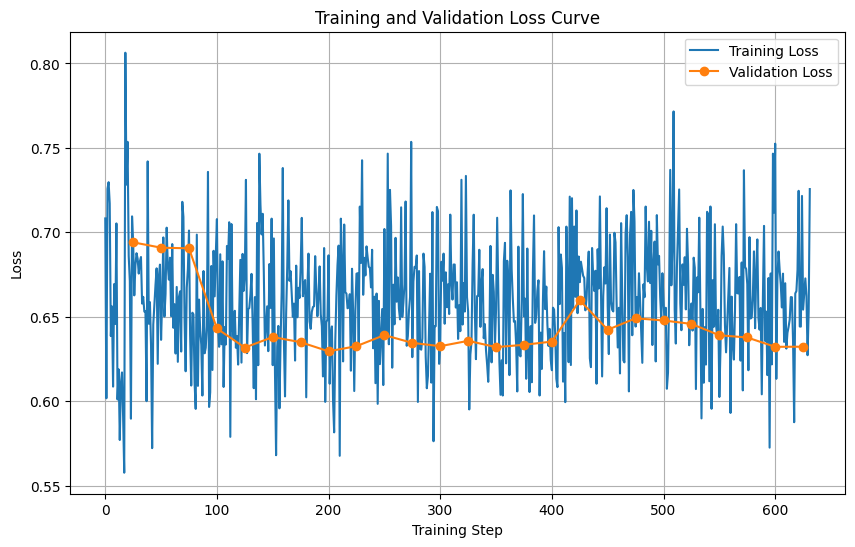

training done!


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

progress: 0/632
progress: 100/632
progress: 200/632
progress: 300/632
progress: 400/632
progress: 500/632
progress: 600/632
0.6318327974276527 0.002822489924811798
after training results: acc:0.6318327974276527 and avg_speed:0.002822489924811798


In [14]:
train_model(model_2, train_loader, val_quick, device, 1, lr_op=5e-5)
print("training done!")

val_qfull = qqp_preprocessed['validation']
val_full = torch.utils.data.DataLoader(
    val_qfull, batch_size=64, shuffle=False, collate_fn=transformers.default_data_collator, num_workers=4
)
accuracy, speed_per_sample = evaluate_val_accuracy(model_2, val_full, device)
print(f"after training results: acc:{accuracy} and avg_speed:{speed_per_sample}")
# val accuracy was 0.38 now it is 0.42

0.6318327974276527 0.002822489924811798
after training results: acc:0.6318327974276527 and avg_speed:0.002822489924811798

In [15]:
MAX_LENGTH = 128

def classify(model, tokenizer, text1, text2, device='cuda'):
    model.eval()
    inputs = tokenizer(
        text1, text2,
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = F.softmax(logits, dim=-1).squeeze(0)

        predicted_class = torch.argmax(probs).item()

    return predicted_class, probs.tolist()

pred_class, pred_probs = classify(model_2, tokenizer_2,
                                  "how to cook?", "delicious meal is easy to make!",
                                  device=device)
print("Predicted class:", pred_class)
print("Class probabilities:", pred_probs)

Predicted class: 0
Class probabilities: [0.6176331639289856, 0.3823668956756592]


Predicted class: 0
Class probabilities: [0.6176331639289856, 0.3823668956756592]

__Bonus:__ for bonus points, try to find a way to run the function faster than just passing over all questions in a loop. For isntance, you can form a short-list of potential candidates using a cheaper method, and then run your tranformer on that short list. If you opted for this solution, please keep both the original implementation and the optimized one - and explain briefly what is the difference there.